In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import os

In [2]:
os.getcwd()

'C:\\Users\\pmgho'

In [2]:
os.chdir('C:\\Users\\pmgho\\OneDrive\\Desktop\\image_classification_using_multilayer_perceptron(MLP)')

In [3]:
dataset_path = os.listdir('Room_Data')

In [4]:
room_types = os.listdir('Room_Data')
print(room_types)

['Bedroom', 'Dinning', 'Livingroom']


In [5]:
print('Types of rooms found:',len(dataset_path))

Types of rooms found: 3


In [7]:
rooms = []

for item in room_types:
 # Get all the file names
 all_rooms = os.listdir('Room_Data' + '/' +item)
 #print(all_shoes)

 # Add them to the list
 for room in all_rooms:
    rooms.append((item, str('Room_Data' + '/' +item) + '/' + room))
    print(rooms[:1])

[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom', 'Room_Data/Bedroom/bed_1.jpg')]
[('Bedroom

- **Build a dataframe**

In [8]:
rooms_df = pd.DataFrame(data=rooms, columns=['room type', 'image'])
print(rooms_df.head())
print(rooms_df.tail())

  room type                          image
0   Bedroom    Room_Data/Bedroom/bed_1.jpg
1   Bedroom   Room_Data/Bedroom/bed_10.jpg
2   Bedroom  Room_Data/Bedroom/bed_100.jpg
3   Bedroom  Room_Data/Bedroom/bed_101.jpg
4   Bedroom  Room_Data/Bedroom/bed_102.jpg
      room type                               image
572  Livingroom  Room_Data/Livingroom/living_95.jpg
573  Livingroom  Room_Data/Livingroom/living_96.jpg
574  Livingroom  Room_Data/Livingroom/living_97.jpg
575  Livingroom  Room_Data/Livingroom/living_98.jpg
576  Livingroom  Room_Data/Livingroom/living_99.jpg


- **Let's check how many samples for each category are present**

In [9]:
print("Total number of rooms in the dataset: ", len(rooms_df))

Total number of rooms in the dataset:  577


In [10]:
room_count = rooms_df['room type'].value_counts()

print("rooms in each category: ")
print(room_count)

rooms in each category: 
room type
Dinning       220
Livingroom    181
Bedroom       176
Name: count, dtype: int64


In [11]:
import cv2
path = 'Room_Data/'


#im_size = 100
im_size = 300

images = []
labels = []

for i in room_types:
    data_path = path + str(i)  # entered in 1st folder and then 2nd folder and then 3rd folder
    #filenames = [i for i in os.listdir(data_path) if i.endswith('.jpg')]
    filenames = [i for i in os.listdir(data_path) ]
   # print(filenames)  # will get the names of all images which ends with .jpg extension
    for f in filenames:
        img = cv2.imread(data_path + '/' + f)  # reading that image as array
        #print(img)  # will get the image as an array
        img = cv2.resize(img, (im_size, im_size))
        images.append(img)
        labels.append(i)

- Transform the image array to a numpy type

In [12]:
images = np.array(images)
images.shape

(577, 300, 300, 3)

In [13]:
images = images.astype('float32') / 255.0

In [15]:
images.shape

(577, 300, 300, 3)

In [16]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

In [17]:
y=rooms_df['room type'].values
print(y[:5])

['Bedroom' 'Bedroom' 'Bedroom' 'Bedroom' 'Bedroom']


- **for y**

In [18]:
y_labelencoder = LabelEncoder ()
y = y_labelencoder.fit_transform (y)
print (y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 

- **y=y.reshape(-1,1)**

- **onehotencoder = OneHotEncoder(categorical_features=[0])**

- ***Converted  scalar output into vector output where the correct class will be 1 and other will be 0***

- **Y= onehotencoder.fit_transform(y)**

- **Y.shape**  #(393, 3)

In [19]:
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
images, y = shuffle(images, y, random_state=1)
train_x, test_x, train_y, test_y = train_test_split(images, y, test_size=0.05, random_state=415)
#inpect the shape of the training and testing.
print(train_x.shape)
print(train_y.shape)
print(test_x.shape)
print(test_y.shape)

(548, 300, 300, 3)
(548,)
(29, 300, 300, 3)
(29,)


- **no need to reshape the image as keras will accept 2 dimensional iage and we are using flatten layer there to convert this image into 1 dimensional image.**

- **train_x=np.reshape(train_x,(373,30000))**

- **print(train_x.shape)**

- **test_x=np.reshape(test_x,(20,30000))**
- **test_x.shape**

- Develop a sequential model using tensorflow keras

In [20]:
import keras
import tensorflow as tf
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(300,300,3)),
    keras.layers.Dense(256, activation=tf.nn.tanh),
   
    keras.layers.Dense(3, activation=tf.nn.softmax)
])

C:\Users\pmgho\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 270000)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      69,120,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 69,121,027 (263.68 MB)

 Trainable params: 69,121,027 (263.68 MB)

 Non-trainable params: 0 (0.00 B)

- **Compute the model parameters**

In [24]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

- Train the model  with 5 epochs 

In [25]:
model.fit(train_x,train_y, epochs=5)

Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.3741 - loss: 6.7392
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 965ms/step - accuracy: 0.3540 - loss: 4.6263
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 981ms/step - accuracy: 0.3321 - loss: 2.1208
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.3394 - loss: 1.1560
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 997ms/step - accuracy: 0.3832 - loss: 1.1134


In [28]:
import numpy as np

y_pred = np.argmax(model.predict(test_x), axis=1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2], dtype=int64)

- Take input from user

In [32]:
import os
print(os.listdir())

['Room_Data']


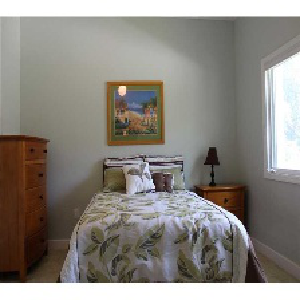

In [38]:
image = load_img(r'C:\\Users\\pmgho\\OneDrive\\Desktop\\image_classification_using_multilayer_perceptron(MLP)\\Room_Data\Bedroom\\bed_10.jpg',target_size=(300,300))
image

- convert the image pixels to a numpy array

In [40]:
image = np.array(image)
image.shape

(300, 300, 3)

- reshape data for the model

In [41]:
image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))

In [42]:
yhat = model.predict(image)
yhat

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step


array([[0.32436132, 0.3362538 , 0.33938485]], dtype=float32)